**Question 3**: 
Implement a genetic algorithm that can suggest a good next move. Apply the
concepts learned in class to write a good genetic algorithm with the right mutation and
recombination setup. You are allowed to include other techniques than just genetic algorithms
based on your research, but genetic algorithms or alternatives must be the core of your solution.
Look for a good fitness function and explain your method. You must analyze how different
configurations of the genetic algorithm affect performance and document key observations
from the optimization process.

Start with:
Individual = single legal move
Genome representation: (from_square, to_square, promotion_piece)
Fitness = material + small positional terms
No crossover, only mutation
When mutating:
Change to
Change from
Randomly change promotion (if legal)
Fitness function
Material score: 
    Pawn   = 1
    Knight = 3
    Bishop = 3
    Rook   = 5
    Queen  = 9
    King   = very large (or not counted)
    fitness = material_after_move - material_before_move
    fitness =
        material_score
        + 0.1 × mobility
        + 0.2 × center_control
        + 0.5 × check_or_checkmate
        - 0.3 × king_exposure
    Where:
        mobility = number of legal moves after your move
        center control = pieces attacking e4, d4, e5, d5
        check / checkmate = bonus if opponent is in check
        king exposure = penalty if your king is attacked
Compare results vs random move selection

In [ ]:
%pip install deap
%pip install python-chess
# restart kernel after install

In [2]:
import chess
import random
from deap import base, creator, tools, algorithms
import operator
import functools
import numpy as np

In [3]:
board = chess.Board()
print(board)

r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
P P P P P P P P
R N B Q K B N R


# Create methods

In [4]:
def move_to_individual(move):    
    # Convert move to tuple representation: (from_square, to_square, promotion)
    from_square = move.from_square # Get the from_square index by number a1=0, b1=1, ..., h8=63
    to_square = move.to_square
    promotion = move.promotion if move.promotion else 0 # pawn moves to opposite of the board and can promote to queen, rook, bishop, knight
    individual = creator.Individual([from_square, to_square, promotion])
    return individual

In [5]:
def create_individual(board):
    moves = list(board.legal_moves)
    move = random.choice(moves)
    individual = move_to_individual(move)
    return individual

In [6]:
def create_population(board, n):
    pop = []
    legal_moves = list(board.legal_moves)
    for _ in range(0, n):
        move = random.choice(legal_moves)
        pop.append(move_to_individual(move))
    return pop


In [7]:
PIECE_VALUES = {
    chess.PAWN:   1,
    chess.KNIGHT: 3,
    chess.BISHOP: 3,
    chess.ROOK:   5,
    chess.QUEEN:  9,
    chess.KING:   0  # king handled separately
}


In [8]:
def material_score(board, color):
    score = 0
    for piece_type, value in PIECE_VALUES.items():
        score += len(board.pieces(piece_type, color)) * value
        score -= len(board.pieces(piece_type, not color)) * value
    return score


In [9]:
# https://chessfox.com/how-to-measure-center-control-in-chess/
CENTER_SQUARES = [
    chess.E4, chess.D4, chess.E5, chess.D5
]

def center_control(board, color):
    control = 0
    for sq in CENTER_SQUARES:
        if board.is_attacked_by(color, sq):
            control += 1
        if board.is_attacked_by(not color, sq):
            control -= 1
    return control


In [10]:
def calculate_score(board, color):

    material = material_score(board, color)

    # Mobility
    mobility = board.legal_moves.count()

    # Center control
    center = center_control(board, color)

    # Check / checkmate bonus
    check_bonus = 0
    if board.is_checkmate():
        check_bonus = 100
    elif board.is_check():
        check_bonus = 5

    # King safety (simple)
    king_square = board.king(color)
    king_exposure = 0
    if king_square is not None:
        attackers = board.attackers(not color, king_square)
        king_exposure = len(attackers)

    return material, mobility, center, check_bonus, king_exposure 

In [11]:
# Beyond Material, the most commonly cited categories of heuristics are King Safety, Space, Pawn Structure, and Piece Activity and Coordination. (From https://joachimkennedy.com/p/chess/)

# Material. The easiest one to evaluate: just count up the value of your pieces vs. the value of your opponent's pieces. Pawn = 1, bishop/knight = 3, rook = 5, and queen = 9 is generally a good rule.
# Pawn structure. Isolated, passed, chained, backward, doubled, tripled, quadrupled (I have seen this happen): identify them in both your position and in your opponent's. Check also for any open files or half-open files either of you may have as a result of the pawn structure. You can also determine, using the pawn structure, the nature of the position: is it a closed position (the center is blocked by pawns) or an open position (the center is relatively free of pawns, with open files and diagonals)?
# Space. Technically this would be done by counting up the squares controlled by each side, but it's pretty easy to gauge a spatial advantage by examining the pawns, which tend to mark out space both by forming a frontier between the two sides and by denying squares to the opponent.
# Weak squares / strong squares. Are there any squares that can't be protected by pawns? Also note that your weak squares are only really weak if they can be turned into strong squares for the opponent.
# Minor piece imbalance. Easy to take stock of; difficult to evaluate. Do you have the same minor pieces (bishops and knights) as your opponent, or is it a bishop vs. knight situation? If it's bishop vs. bishop, are they on squares of the same color? Two bishops vs. knight and bishop? You get the idea.
# Development. Who has more pieces out?
# King safety. Are there any structural weaknesses in either king's position? Does one player have a bunch of attacking pieces near the opponent's king?
# Initiative. This is probably the most difficult of all of them to figure out: the initiative is the ability to dictate the tempo of the game. Generally speaking, the initiative belongs to the player who is able to make threats, positional or tactical. The player with the initiative makes the opponent's plan subservient to his own--you will carry out your plan only if I want you to, and only on my terms.
# from https://www.quora.com/What-are-some-heuristics-for-quickly-evaluating-chess-positions

# Static Board Evaluation Function
# When the min-max algorithm gets down to the leaves of its search, it's unlikely that it reached a goal state (i.e. a check-mate).
# Therefore, it needs some way to determine whether the given board position is "good" or "bad" for it, and to what degree.
# A numerical answer is needed so that it can be compared to other board positions in a quantifiable way. Advanced chess
# playing programs can look at hundreds features of the board to evalaute it. The simplest, and perhaps most intuitive, look
# at only piece possession. Clearly, having a piece is better than not having one (in most cases at least). Furthermore, the
# pieces have different values. A pawn is worth the least; the bishop and knight are next, then the rook, and finally: the queen.
# The king is obviously priceless, as losing it means losing the game.
# 
# The additional features that my chess program examines are:
# 
# - pawn advancement
# How far up the board has each pawn advanced. Reaching the opposite end is important because it promotes the pawn to a different piece.
# 
# - piece mobility (separate for each type of piece)
# How many different spaces can the given piece move to?
# 
# - piece threats (separate for each type of piece)
# How many of the opponent's pieces are threatened by attack? This includes checks (which is a threat on the king)
# 
# - piece protects (separate for each type of piece)
# How many of your own piece are protecting the given piece to prevent it from being captured without reprecussion?
# 
# The total number of unique numbers that sum up to give the total board score is thus 25. The allowable weights for each
# feature are forced to be integers. This allows for faster computations (as opposed to using real numbers). This isn't a real
# loss of generality though, as the scale of numbers used can be large (very large integers to represent piece possession, and
# small ones to represent the other features). 
# from https://www.cs.cornell.edu/boom/2004sp/ProjectArch/Chess/chessreport.html

# Material parameters
# Positional parameters
#   king safety, centrality, bishop pairs
#   knights on outposts, knight mobility
#   doubled, isolated, passed pawns
# from https://www.cmpe.boun.edu.tr/content/tuning-chess-evaluation-function-using-genetic-algorithm

def evaluate_fitness(individual, board):

    board_copy = board.copy()
    from_sq, to_sq, promotion = individual
    color = board_copy.turn
    movesearch = chess.Move(from_sq, to_sq, promotion=None)
    move = chess.Move(from_sq, to_sq, promotion=promotion)
    moves=list(board_copy.legal_moves)

    if movesearch not in moves:
        print("illegal move found")
        return (-1000,)
        

    # Evaluate BEFORE move
    material_before = material_score(board_copy, color)


    # Play the move
    board_copy.push(move)

    material_after, mobility, center, check_bonus, king_exposure = calculate_score(board_copy, color)


    material_delta = material_after - material_before

    # Undo move
    board_copy.pop()

    # Final fitness
    fitness_value = (
        1.0 * material_delta +
        0.1 * mobility +
        0.2 * center +
        0.5 * check_bonus -
        0.3 * king_exposure
    )

    return (fitness_value,)


In [13]:
def crossover(ind1, ind2):
    # don't cross over
    return ind1.copy(), ind2.copy()

In [14]:
def selElitistAndRoulette(individuals, pop_size, k_elitist):
    return tools.selBest(individuals, k_elitist) + tools.selRoulette(individuals, pop_size - k_elitist)

In [15]:
def individual_to_move(ind):
    promotion = ind[2] if ind[2] != 0 else None
    return chess.Move(ind[0], ind[1], promotion=promotion)

def is_legal_individual(ind, board):
    move = individual_to_move(ind)
    return move in board.legal_moves

def individual_key(ind):
    return tuple(ind)  # (from, to, promotion)

def mutate(individual, board):
    """
    Mutate a chess move individual represented as:
    [from_square, to_square, promotion]
    """

    legal_moves = list(board.legal_moves)

    # Safety check (should not happen often)
    if not legal_moves:
        return individual,

    if random.random() < 0.5:
        # ---- Mode A: same from_square, different target ----
        from_sq = individual[0]

        candidates = [
            m for m in legal_moves
            if m.from_square == from_sq
        ]

        if candidates:
            move = random.choice(candidates)
        else:
            # fallback if no alternative move exists
            move = random.choice(legal_moves)

    else:
        # ---- Mode B: completely new legal move ----
        move = random.choice(legal_moves)

    # Update genes in-place
    individual[0] = move.from_square
    individual[1] = move.to_square
    individual[2] = move.promotion if move.promotion else 0

    return individual,



## Testen van 1 laag diep op spelletjes die één stap voor schaakmat zijn

- dpa algoritme aangepast zodat illegal moves onthouden worden en niets terug komen met crossover
- crossover wordt tot een minimum gereduceerd want in het schaken heeft dit niet veel betekenis, 2 zetten combineren tot een nieuwe zet heeft meestal een illegal move. Vandaar is functie van crossover, gewoon een kopie nemen. 
- voornamelijk werken met mutatie, de mutatie zo ingesteld dat in 50% v/d gevallen vanuit het zelfde vakje start. Mutatie wordt een nieuwe functie die dus vanuit een zet andere zetten zoekt, ofwel soms naar een andere random zet gaat
- we evalueren of het algoritme gemakkelijk de check mate of check zet vindt van het spel
- we evalueren of er illegal zet's gebeuren en houden ze bij, echter gezien crossover niet geimplementeerd is en gewoon kopieert, zijn er nu geen illegal zetten.

In [16]:
#Inlezen van spelletjes die wit in 1 zet zwart schaakmat zet
import os
import chess
import chess.pgn

PGN_PATH = "Game/lichess_db_standard_rated_2017-02.pgn"
MAX_SAMPLES = 1000


def parse_pgn_extract_mate_in_1_white(pgn_path, max_samples=MAX_SAMPLES):
    """
    Parse PGN file and extract positions one move before Black is checkmated
    by White.

    Returns list of:
        (fen_before_mate, mating_move_uci, white_wins)
    """
    samples = []

    if not os.path.exists(pgn_path):
        raise FileNotFoundError(f"PGN file not found: {pgn_path}")

    with open(pgn_path, "r", encoding="utf-8") as f:
        games = 0

        while True:
            game = chess.pgn.read_game(f)
            if game is None:
                break

            games += 1

            # Optional fast filter: White must win
            result = game.headers.get("Result", "")
            if result != "1-0":
                continue

            board = game.board()

            for move in game.mainline_moves():
                fen_before = board.fen()
                turn_before = board.turn  # True = White, False = Black

                board.push(move)

                # Check: did White just deliver checkmate or stalemate?
                if (
                    (board.is_checkmate() or board.is_check())
                    and turn_before == chess.WHITE  # White made the move
                ):
                    samples.append(
                        (
                            fen_before,
                            move.uci(),
                            True  # white_wins
                        )
                    )

                    if len(samples) >= max_samples:
                        break

            if len(samples) >= max_samples:
                break

    print(f"Parsed {len(samples)} mate-in-1 samples from {games} games.")
    return samples


samples = parse_pgn_extract_mate_in_1_white(PGN_PATH, MAX_SAMPLES)


Parsed 1000 mate-in-1 samples from 532 games.


In [17]:
n_population = 10
crossover_per = 0.1 # heeft eigenlijk geen betekenis, gewoon kopieren van ouders uit de vorige generatie
mutation_per = 0.6
n_generations = 200


Bord waarvan we vertrekken met het aantal mogelijke moves, de move waarbij check of checkmate bekomen is.

In [19]:
idx = random.randrange(len(samples))
fen, move_uci, white_wins = samples[idx]

board = chess.Board(fen)
move = chess.Move.from_uci(move_uci)

print("Number of legal moves on the board:", len(list(board.legal_moves)))
print("=== BOARD BEFORE MOVE ===")
print(board)
print("\nSide to move:", "White" if board.turn else "Black")

print("\nMating move (UCI):", move_uci)
print("Mating move (SAN):", board.san(move))

board.push(move)

print("\n=== BOARD AFTER MOVE ===")
print(board)

print("\nCheckmate:", board.is_checkmate())
print("\nCheck:", board.is_check())
print("Winner:", "White" if white_wins else "Black")

Number of legal moves on the board: 23
=== BOARD BEFORE MOVE ===
. . . . . . . .
. . . . . . R .
. . . . . . . .
. . p . . . . p
. . P . . . . P
. . . . . . P k
P . . . . . . r
. . . . . . K Q

Side to move: White

Mating move (UCI): h1h2
Mating move (SAN): Qxh2#

=== BOARD AFTER MOVE ===
. . . . . . . .
. . . . . . R .
. . . . . . . .
. . p . . . . p
. . P . . . . P
. . . . . . P k
P . . . . . . Q
. . . . . . K .

Checkmate: True

Check: True
Winner: White


In [20]:
def run_ga_deap(n_pop, n_gen, cxpb, mutpb, board):
    """
    Run genetic algorithm using DEAP to find best move on a fixed board
    """
    # Create population with individuals that are legal moves on this board
        # 🔹 Track fitness over generations
    
    best_fitness_deap = []
    avg_fitness_deap = []
    pop = create_population(board, n_pop)
    hof = tools.HallOfFame(1)
    illegal_moves_seen = set()

    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("min", np.min)
    stats.register("max", np.max)

    # Evaluate initial population on the SAME board
    fitnesses = [evaluate_fitness(ind, board) for ind in pop]
    print("Lengte pop: "+str(len(pop))+"Lengte evaluaties: "+str(len(fitnesses)))
    for ind, fit in zip(pop, fitnesses):
        ind.fitness.values = fit

    logbook = tools.Logbook()
    logbook.record(gen=0, nevals=len(pop), **stats.compile(pop))
    
    best_fitness_so_far = max([ind.fitness.values[0] for ind in pop])
    print(f"Gen 0: Best fitness = {best_fitness_so_far:.4f}")

    k_elitist = int(0.1 * n_pop)

    for gen in range(1, n_gen + 1):
        elites = tools.selBest(pop, k_elitist)
        elite_fitness = [ind.fitness.values[0] for ind in elites]
        print(f"\nGen {gen}: Elite fitness before = {max(elite_fitness):.4f}")
        
        offspring = toolbox.select(pop, n_pop - k_elitist)
        offspring = [toolbox.clone(ind) for ind in offspring]
        #--- CROSSOVER ---
        for i in range(1, len(offspring), 2):
            if random.random() < cxpb:
                toolbox.mate(offspring[i - 1], offspring[i])
                del offspring[i - 1].fitness.values
                del offspring[i].fitness.values
        #--- MUTATION ---
        for i in range(len(offspring)):
            if random.random() < mutpb:
                toolbox.mutate(offspring[i])
                del offspring[i].fitness.values
        # -------- Illegal move handling --------
        repaired_offspring = []
        for ind in offspring:
            key = individual_key(ind)

            if key in illegal_moves_seen:
                # Known illegal → replace
                repaired_offspring.append(create_individual(board))
                continue

            if not is_legal_individual(ind, board):
                illegal_moves_seen.add(key)
                repaired_offspring.append(create_individual(board))
            else:
                repaired_offspring.append(ind)
        # --- Fill up if needed due to blacklisted offspring ---
        while len(repaired_offspring) < (n_pop - k_elitist):
            repaired_offspring.append(create_individual(board))
        offspring = repaired_offspring
        # Evaluate offspring on the SAME board
        for ind in offspring:
            ind.fitness.values = evaluate_fitness(ind, board)

        pop = elites + offspring
        print(pop)
        print(fitnesses)
        print("Illegale zetten gezien: "+str(len(illegal_moves_seen)))
        print("Lengte pop: "+str(len(pop))+"Lengte evaluaties: "+str(len(fitnesses)))
        pop_best = max([ind.fitness.values[0] for ind in pop])
        print(f"Gen {gen}: Best in combined pop = {pop_best:.4f}")
       
        
        if max(elite_fitness) > pop_best:
            print(f"⚠️  WARNING: Elite fitness {max(elite_fitness):.4f} > pop best {pop_best:.4f}")

        hof.update(pop)
        record = stats.compile(pop)
        best_fitness_deap.append(pop_best)
        avg_fitness_deap.append(record["avg"])
        
        current_max = record['max']
        print(f"Gen {gen}: Max fitness = {current_max:.4f}, Avg = {record['avg']:.4f}")
        
        if current_max < best_fitness_so_far:
            print(f"❌ DECREASE: {best_fitness_so_far:.4f} → {current_max:.4f}")
        else:
            best_fitness_so_far = current_max

    return pop, hof, logbook, best_fitness_deap, avg_fitness_deap

=== BOARD BEFORE MOVE ===
. . . . . . . .
. . . . . . R .
. . . . . . . .
. . p . . . . p
. . P . . . . P
. . . . . . P k
P . . . . . . r
. . . . . . K Q
Running DEAP Genetic Algorithm for Chess Move Selection...
Population: 10, Generations: 200
Crossover: 0.1, Mutation: 0.6

Lengte pop: 10Lengte evaluaties: 10
Gen 0: Best fitness = 2.8000

Gen 1: Elite fitness before = 2.8000
[[7, 14, 0], [54, 46, 0], [54, 38, 0], [7, 28, 0], [7, 21, 0], [54, 51, 0], [54, 46, 0], [7, 21, 0], [7, 42, 0], [7, 35, 0]]
[(0.7000000000000001,), (1.0,), (0.30000000000000004,), (0.7000000000000001,), (1.2000000000000002,), (2.8,), (0.30000000000000004,), (0.30000000000000004,), (1.0,), (1.0,)]
Illegale zetten gezien: 0
Lengte pop: 10Lengte evaluaties: 10
Gen 1: Best in combined pop = 2.8000
Gen 1: Max fitness = 2.8000, Avg = 1.0200

Gen 2: Elite fitness before = 2.8000
[[7, 14, 0], [7, 35, 0], [7, 14, 0], [7, 42, 0], [54, 38, 0], [54, 30, 0], [7, 15, 0], [54, 49, 0], [7, 21, 0], [7, 14, 0]]
[(0.70000000000000

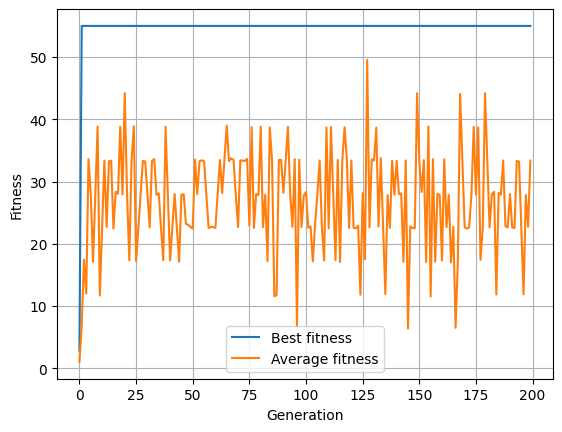

In [21]:
# Clear any existing fitness/individual classes
import matplotlib.pyplot as plt
if hasattr(creator, "FitnessMax"):
    del creator.FitnessMax
if hasattr(creator, "Individual"):
    del creator.Individual

# Create fitness class for MAXIMIZATION
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

# Initialize DEAP toolbox
toolbox = base.Toolbox()
# Fixed board for evaluation
eval_board = chess.Board(fen)
print("=== BOARD BEFORE MOVE ===")
print(eval_board)

# Register operators
toolbox.register("individual", functools.partial(create_individual, eval_board))
toolbox.register("population", functools.partial(create_population, eval_board))
toolbox.register("evaluate", functools.partial(evaluate_fitness, board=eval_board))

toolbox.register("mate", crossover)
toolbox.register("mutate", mutate, board=eval_board)
toolbox.register("select", selElitistAndRoulette, k_elitist=int(0.1*n_population))

# Execute DEAP GA
print("Running DEAP Genetic Algorithm for Chess Move Selection...")
print(f"Population: {n_population}, Generations: {n_generations}")
print(f"Crossover: {crossover_per}, Mutation: {mutation_per}\n")

pop_deap, hof_deap, logbook_deap,bestfit,avgfit = run_ga_deap(n_population, n_generations, 
                                                    crossover_per, mutation_per, eval_board)

# Extract best solution
best_individual_deap = hof_deap[0]
best_fitness_deap = evaluate_fitness(best_individual_deap, eval_board)

print("\n" + "="*50)
print("DEAP GA Results")
print("="*50)
print(f"Best evaluation found: {best_fitness_deap[0]:.3f}")
bestmove=chess.Move(best_individual_deap[0], best_individual_deap[1], best_individual_deap[2])
print(f"Best move: {bestmove}")
plt.plot(bestfit, label="Best fitness")
plt.plot(avgfit, label="Average fitness")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend()
plt.grid(True)
plt.show()

Finale controle of the best move van GA ook effectief check of checkmate uitlokt

In [22]:
fen, move_uci, white_wins = samples[idx]

board = chess.Board(fen)
move = chess.Move.from_uci(move_uci)
print("Predicted move by GA",bestmove)
print("=== BOARD BEFORE MOVE ===")
print(board)
print("\nSide to move:", "White" if board.turn else "Black")

print("\nMating move by historical game (UCI):", bestmove)

board.push(bestmove)

print("\n=== BOARD AFTER MOVE ===")
print(board)

print("\nCheckmate:", board.is_checkmate())
print("\nCheck:", board.is_check())
print("Winner:", "White" if white_wins else "Black")

Predicted move by GA h1h2
=== BOARD BEFORE MOVE ===
. . . . . . . .
. . . . . . R .
. . . . . . . .
. . p . . . . p
. . P . . . . P
. . . . . . P k
P . . . . . . r
. . . . . . K Q

Side to move: White

Mating move by historical game (UCI): h1h2

=== BOARD AFTER MOVE ===
. . . . . . . .
. . . . . . R .
. . . . . . . .
. . p . . . . p
. . P . . . . P
. . . . . . P k
P . . . . . . Q
. . . . . . K .

Checkmate: True

Check: True
Winner: White


# Add multiply lookahead

## multi move genome methods

Plan: Sequence-Based Individuals
Change Individual from a single move to a sequence of moves (your side's plan over several plies). The GA evolves these sequences via crossover and mutation, and fitness evaluates how good the resulting position is after playing out the sequence against an opponent model (static eval, random moves, or Stockfish).

Steps
Genome redesign: Individual = [(from₁, to₁, promo₁), (from₂, to₂, promo₂), ...] for K=2–4 moves representing your side's plan.
Creation: Generate sequences by iteratively picking random legal moves, alternating with opponent moves (random or greedy); store only your moves in the genome.
Fitness evaluation: Push the sequence move-by-move, intersperse opponent replies (random, greedy eval, or Stockfish), reach depth D, evaluate with static_eval() or engine analysis, pop back.
Mutation: randomly replace one move in the sequence with a different legal move at that ply; use legal repair to fix invalidated follow-ups after board state changes.
Crossover: splice two parent sequences at a random ply index; repair legality by replaying from the splice point and generating legal continuations.
Legal repair: after any genetic op, replay the sequence; if a move is illegal, replace it with a random legal move and regenerate remaining plies.
Further Considerations
Opponent model: For fitness, alternate your sequence moves with opponent moves—use random (fast), greedy static eval (balanced), or Stockfish engine.play() (strong but slow).
Sequence length: Start with K=2 (your 2 moves over 4 plies); longer sequences increase search space exponentially but give GA more planning power.
Diversity: Sequences naturally provide more diversity than single moves; crossover becomes meaningful by combining early/late-game plans from two parents.
Comparison: Benchmark against single-move GA + negamax to show whether GA-evolved sequences outperform or provide different strategic insights.

In [34]:
n_population = 250
crossover_per = 0.8
mutation_per = 0.2
n_generations = 200
n_moves = 4 # number of moves in a genome

In [35]:
def create_multi_individual(board):
    board_copy = board.copy()
    individual = creator.Individual([])
    for _ in range (0, n_moves):
        # choose a legal move
        move = random.choice(list(board_copy.legal_moves))   
        # add the move the the genome        
        individual.append(move_to_individual(move))
        # add the move to the board
        board_copy.push(move)
        # add a move to the board for the opponent, maybe we can make this smarter?
        if board_copy.legal_moves.count() > 0:
            opponent_move = random.choice(list(board_copy.legal_moves))
            board_copy.push(opponent_move)
        else:
            break

    return individual

In [36]:
def create_multi_population(board, n):
    pop = []
    for _ in range(0, n):
        pop.append(create_multi_individual(board))
    return pop

In [37]:
def static_eval(board, color):
    """
    Evaluate board position from the perspective of `color`.
    Uses material + mobility + center control + check bonus - king exposure.
    """
    material, mobility, center, check_bonus, king_exposure = calculate_score(board, color)
    
    eval_score = (
        1.0 * material +
        0.1 * mobility +
        0.2 * center +
        0.5 * check_bonus -
        0.3 * king_exposure
    )
    return eval_score

In [38]:
def get_greedy_opponent_move(board):
    """
    Opponent plays greedily: picks the move that maximizes static_eval
    from their perspective.
    """
    legal_moves = list(board.legal_moves)
    if not legal_moves:
        return None
    
    best_move = None
    best_score = float('-inf')
    opponent_color = board.turn
    
    for move in legal_moves:
        board.push(move)
        score = static_eval(board, opponent_color)
        board.pop()
        
        if score > best_score:
            best_score = score
            best_move = move
    
    return best_move

In [39]:
def evaluate_multi_fitness(individual, board, num_opponent_moves=n_moves/2):
    """
    Evaluate a sequence of moves (individual) by:
    1. Play your moves from the sequence
    2. Opponent replies greedily (using static_eval)
    3. Repeat for num_opponent_moves opponent replies
    4. Evaluate final position using static_eval
    
    Returns fitness as a tuple (score,) for DEAP.
    """
    board_copy = board.copy()
    your_color = board_copy.turn
    
    # Play out the sequence of your moves, interleaved with opponent replies
    for move_tuple in individual:
        from_sq, to_sq, promotion = move_tuple
        your_move = chess.Move(from_sq, to_sq, promotion=promotion)
        
        # Check if your move is legal
        if your_move not in board_copy.legal_moves:
            return (-1000,)  # Illegal move → penalty
        
        # Play your move
        board_copy.push(your_move)
        
        # Check for terminal state
        if board_copy.is_game_over():
            # Checkmate/stalemate for you (good for checkmate, neutral for stalemate)
            if board_copy.is_checkmate():
                return (1000,)  # You won
            else:
                return (0,)  # Draw/stalemate
        
        # Opponent replies greedily
        opponent_move = get_greedy_opponent_move(board_copy)
        if opponent_move is None:
            # Opponent has no legal moves (stalemate/checkmate)
            if board_copy.is_checkmate():
                return (1000,)  # You delivered checkmate
            else:
                return (0,)  # Stalemate
        
        board_copy.push(opponent_move)
        
        # Check if opponent just checkmated you
        if board_copy.is_checkmate():
            return (-1000,)  # Opponent won
    
    # Evaluate final position from your perspective
    final_eval = static_eval(board_copy, your_color)
    
    return (final_eval,)


In [40]:
def crossover_multi(ind1, ind2):
    """
    Crossover for sequence-based individuals.
    Randomly selects a crossover point and swaps the tails.
    """
    if len(ind1) < n_moves or len(ind2) < n_moves:
        return ind1, ind2
    
    # Choose crossover point (1 to len-1 to ensure both parts exist)
    cx_point = random.randint(1, min(len(ind1), len(ind2)) - 1)
    
    # Create new individuals by swapping tails
    new_ind1 = creator.Individual(ind1[:cx_point] + ind2[cx_point:])
    new_ind2 = creator.Individual(ind2[:cx_point] + ind1[cx_point:])
    
    return new_ind1, new_ind2


In [41]:
def run_ga_deap_multi(n_pop, n_gen, cxpb, mutpb, board):
    # Create population 
    pop = create_multi_population(board, n_pop)
    
    hof = tools.HallOfFame(1)

    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("min", np.min)
    stats.register("max", np.max)

    # Evaluate initial population on the SAME board
    fitnesses = [evaluate_multi_fitness(ind, board) for ind in pop]
    for ind, fit in zip(pop, fitnesses):
        ind.fitness.values = fit

    logbook = tools.Logbook()
    logbook.record(gen=0, nevals=len(pop), **stats.compile(pop))
    
    best_fitness_so_far = max([ind.fitness.values[0] for ind in pop])
    print(f"Gen 0: Best fitness = {best_fitness_so_far:.4f}")

    k_elitist = int(0.1 * n_pop)

    for gen in range(1, n_gen + 1):
        elites = tools.selBest(pop, k_elitist)
        elite_fitness = [ind.fitness.values[0] for ind in elites]
        print(f"\nGen {gen}: Elite fitness before = {max(elite_fitness):.4f}")
        
        offspring = toolbox.select(pop, n_pop - k_elitist)
        offspring = [toolbox.clone(ind) for ind in offspring]

        for i in range(1, len(offspring), 2):
            if random.random() < cxpb:
                toolbox.mate(offspring[i - 1], offspring[i])
                del offspring[i - 1].fitness.values
                del offspring[i].fitness.values

        for i in range(len(offspring)):
            if random.random() < mutpb:
                toolbox.mutate(offspring[i])
                del offspring[i].fitness.values

        # Evaluate offspring on the SAME board
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = [evaluate_multi_fitness(ind, board) for ind in invalid_ind]
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        pop = elites + offspring
        
        pop_best = max([ind.fitness.values[0] for ind in pop])
        print(f"Gen {gen}: Best in combined pop = {pop_best:.4f}")
        
        if max(elite_fitness) > pop_best:
            print(f"⚠️  WARNING: Elite fitness {max(elite_fitness):.4f} > pop best {pop_best:.4f}")

        hof.update(pop)
        record = stats.compile(pop)
        logbook.record(gen=gen, nevals=len(invalid_ind), **record)
        
        current_max = record['max']
        print(f"Gen {gen}: Max fitness = {current_max:.4f}, Avg = {record['avg']:.4f}")
        
        if current_max < best_fitness_so_far:
            print(f"❌ DECREASE: {best_fitness_so_far:.4f} → {current_max:.4f}")
        else:
            best_fitness_so_far = current_max

    return pop, hof, logbook

## Run algorithm

In [42]:
# Clear any existing fitness/individual classes
if hasattr(creator, "FitnessMax"):
    del creator.FitnessMax
if hasattr(creator, "Individual"):
    del creator.Individual

# Create fitness class for MAXIMIZATION
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

# Initialize DEAP toolbox
toolbox = base.Toolbox()

# Fixed board for evaluation
eval_board = chess.Board()

# Register operators
toolbox.register("individual", functools.partial(create_multi_individual, eval_board))
toolbox.register("population", functools.partial(create_multi_population, eval_board))
toolbox.register("evaluate", functools.partial(evaluate_multi_fitness, board=eval_board))

toolbox.register("mate", crossover_multi)
toolbox.register("mutate", tools.mutShuffleIndexes, indpb=0.1)
toolbox.register("select", selElitistAndRoulette, k_elitist=int(0.1*n_population))

# Execute DEAP GA
print("Running DEAP Genetic Algorithm for Chess Move Selection...")
print(f"Population: {n_population}, Generations: {n_generations}")
print(f"Crossover: {crossover_per}, Mutation: {mutation_per}\n")

pop_deap, hof_deap, logbook_deap = run_ga_deap_multi(n_population, n_generations, 
                                                    crossover_per, mutation_per, eval_board)

# Extract best solution
best_individual_deap = hof_deap[0]
best_fitness_deap = evaluate_multi_fitness(best_individual_deap, eval_board)

print("\n" + "="*50)
print("DEAP GA Results")
print("="*50)
print(f"Best evaluation found: {best_fitness_deap[0]:.3f}")
print(f"Best sequence (moves):")
for i, move_tuple in enumerate(best_individual_deap):
    move = chess.Move(move_tuple[0], move_tuple[1], move_tuple[2])
    print(f"  Move {i+1}: {move}")

Running DEAP Genetic Algorithm for Chess Move Selection...
Population: 250, Generations: 200
Crossover: 0.8, Mutation: 0.2

Gen 0: Best fitness = -0.3000

Gen 1: Elite fitness before = -0.3000
Gen 1: Best in combined pop = -0.3000
Gen 1: Max fitness = -0.3000, Avg = -240.2280

Gen 2: Elite fitness before = -0.3000
Gen 2: Best in combined pop = -0.3000
Gen 2: Max fitness = -0.3000, Avg = -60.2820

Gen 3: Elite fitness before = -0.3000
Gen 3: Best in combined pop = -0.3000
Gen 3: Max fitness = -0.3000, Avg = -48.2856

Gen 4: Elite fitness before = -0.3000
Gen 4: Best in combined pop = -0.3000
Gen 4: Max fitness = -0.3000, Avg = -48.2856

Gen 5: Elite fitness before = -0.3000
Gen 5: Best in combined pop = -0.3000
Gen 5: Max fitness = -0.3000, Avg = -20.2940

Gen 6: Elite fitness before = -0.3000
Gen 6: Best in combined pop = -0.3000
Gen 6: Max fitness = -0.3000, Avg = -52.2844

Gen 7: Elite fitness before = -0.3000
Gen 7: Best in combined pop = -0.3000
Gen 7: Max fitness = -0.3000, Avg = 